<a href="https://colab.research.google.com/github/varunegit/carisurg-portfolio/blob/main/Week0_Tutorial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import pandas as pan
import numpy as py
import matplotlib.pyplot as plt

#Mount Google Drive onto colab

from google.colab import drive
drive.mount('/content/drive')
print("Google drive mounted")

#Connect the file 'EmergencyTriageDataset_Reduced_Dirty.csv'
filepath = '/content/drive/MyDrive/Colab Notebooks/EmergencyTriageDataset_Reduced_Dirty.csv'
print("\nfile 'EmergencyTriageDataset_Reduced_Dirty.csv' added")

df = pan.read_csv(filepath)

# Re-apply Gender cleaning from Day 1 so we start from a consistent state
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

print(f"\nDataset: {df.shape[0]} rows x {df.shape[1]} columns")
print("FIRST 5 ROWS\n")
print(df.head())
print("\nLAST 5 ROWS\n")
print(df.tail())

#Print the column type and non-null count

print("\n---COLUMN TYPES AND NON-NULL COUNT\n")
df.info()

#Print the statistics for numeric columns

print(f"\nSTATISCS FOR NUMERIC COLUMN\n{df.describe()}")

#print shape of rows and columns
print("\nNUMBER OF ROWS AND COLUMNS\n")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google drive mounted

file 'EmergencyTriageDataset_Reduced_Dirty.csv' added

Dataset: 2205 rows x 11 columns
FIRST 5 ROWS

   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0

LAST 5 ROWS

        ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR  Fio2
2200  2380   65       1  14.0  170   50.0   90.00   65.0  37.0  22.0  21.0
2201  2381   84       0  15.0  180  120.0  140.00   85.0  36.1  18.0  21.0
2202  2382   78       0  15.0  132   78.0   96.00  100.0  37.9  16.0  21.0
2203  23

In [115]:
#Attempt to clean pulse column

#Physiologically valid pulse range <20 BPM too slow to supply enough oxygen
#>250 heart cannot pump blood effectively.
COLUMN = 'pulse'
VALID_MIN = 20
VALID_MAX = 250

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df[COLUMN].unique()[:15]}")
print(f"Dtype: {df[COLUMN].dtype}")
print()

#Convert non-numeric values into NaN
#effectively remove invalid data entries
df[COLUMN] = pan.to_numeric(df[COLUMN], errors='coerce')
print(f"After type conversion — NaNs: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())

=== Cleaning: pulse ===
Unique values: ['128.0' '80.0' '92.0' '100.0' '85.0' '99.0' '78.0' '130.0' '63.0' '98.0'
 '76.0' '166.0' '151.0' '94.0' '87.0']
Dtype: object

After type conversion — NaNs: 44
count    2161.000000
mean       96.094863
std        31.035460
min         0.000000
25%        80.000000
50%        90.000000
75%       108.000000
max       300.000000
Name: pulse, dtype: float64


In [116]:
#Identify pulse values that are outliers and are no valid physiologically
invalid = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range values: {len(invalid)}")

#Replace the invalid values with Nan
df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = py.nan

#Impute — justify your choice
'''Median was used because the Minimum and Maximum value
was 0 and 300 respectively. Since either 0 or 300 were invalid
and do not conform to the physiological range, it means that the data is skewed.
Therefore median is the best choice.
'''

#Replace the Nan using the median
impute_value = df[COLUMN].median()
df[COLUMN] = df[COLUMN].fillna(impute_value)

print(f"\nAfter cleaning:")
print(df[COLUMN].describe())
print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")

Out-of-range values: 43

After cleaning:
count    2205.000000
mean       94.326984
std        19.881720
min        40.000000
25%        80.000000
50%        90.000000
75%       106.000000
max       170.000000
Name: pulse, dtype: float64
NaNs remaining: 0


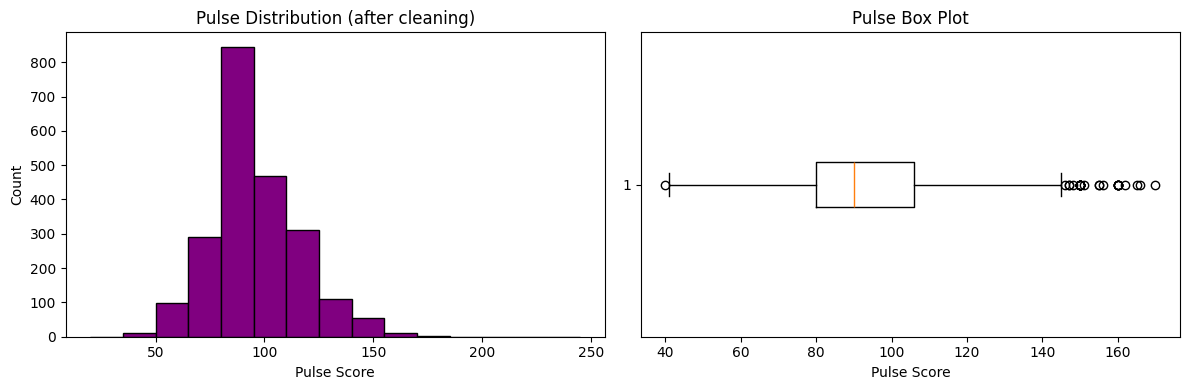


Plot saved as pulse_distribution.png


In [117]:
#Plotting the visuals for the diagram for the pulse
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Plotting the axes for the histogram
axes[0].hist(df['pulse'].dropna(), bins=range(20,250,15), edgecolor='black', color='purple')
axes[0].set_xlabel('Pulse Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Pulse Distribution (after cleaning)')

#Plotting the axes for the Box Plot diagram
axes[1].boxplot(df['pulse'].dropna(), vert=False)
axes[1].set_xlabel('Pulse Score')
axes[1].set_title('Pulse Box Plot')

plt.tight_layout()
plt.savefig('pulse_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nPlot saved as pulse_distribution.png")

In [118]:
#Attempt to clean GCS
COLUMN = 'GCS'
VALID_MIN = 3
VALID_MAX = 15

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df[COLUMN].unique()[:15]}")
print(f"Dtype: {df[COLUMN].dtype}")
print()

#Convert non-numeric data to numeric
df[COLUMN] = pan.to_numeric(df[COLUMN], errors='coerce')
print(f"After type conversion — NaNs: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())

=== Cleaning: GCS ===
Unique values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']
Dtype: object

After type conversion — NaNs: 44
count    2161.000000
mean       14.414160
std         1.386497
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64


In [119]:
#Range filter
invalid = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range values: {len(invalid)}")

df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = py.nan

#Imputed data for the NaNs using median for GCS because the data is skewed
#and has outliers. Median is the best imputation method
impute_value = df[COLUMN].median()
df[COLUMN] = df[COLUMN].fillna(impute_value)

print(f"\nAfter cleaning:")
print(df[COLUMN].describe())
print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")

Out-of-range values: 0

After cleaning:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
NaNs remaining: 0


In [120]:
#Attempt to clean SBP
COLUMN = 'SBP'
VALID_MIN = 50
VALID_MAX = 250

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df[COLUMN].unique()[:15]}")
print(f"Dtype: {df[COLUMN].dtype}")
print()

# Step 1: Convert to numeric- non-numeric entries are changed to Nan
df[COLUMN] = pan.to_numeric(df[COLUMN], errors='coerce')
print(f"After type conversion — NaNs: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())

=== Cleaning: SBP ===
Unique values: ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
Dtype: object

After type conversion — NaNs: 22
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64


In [121]:
#Range filter to set the invalid ranges to Nan Values
invalid = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range values: {len(invalid)}")

df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = py.nan

'''Median were used because the min and max we 30 and 500 respectively.
Therefore the data is skewed, the because imputation technique for skewed data
is median
'''
#Impute the data using the median
impute_value = df[COLUMN].median()
df[COLUMN] = df[COLUMN].fillna(impute_value)

print(f"\nAfter cleaning:")
print(df[COLUMN].describe())
print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")

Out-of-range values: 44

After cleaning:
count    2205.000000
mean      126.626757
std        26.830227
min        55.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       250.000000
Name: SBP, dtype: float64
NaNs remaining: 0


In [122]:
# Write a function to standardise everything to Celsius
def to_celsius(val):
    """Convert temperature value to Celsius float.
    Handles: plain numbers, strings ending in 'C', strings ending in 'F'.
    Returns NaN for anything unrecognisable.
    """
    if pan.isnull(val):
        return py.nan
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])          # remove 'C', convert
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)               # assume Celsius already
    except ValueError:
        return py.nan                           # anything else -> NaN

df['Temp'] = df['Temp'].apply(to_celsius)

print("After standardisation:")
print(df['Temp'].describe())

After standardisation:
count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [123]:
#Attempt to clean Temperature
COLUMN = 'Temp'
VALID_MIN = 32
VALID_MAX = 43

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df[COLUMN].unique()[:15]}")
print(f"Dtype: {df[COLUMN].dtype}")
print()

#Convert to numeric- non-numeric entries are changed to Nan
df[COLUMN] = pan.to_numeric(df[COLUMN], errors='coerce')
print(f"After type conversion — NaNs: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())

=== Cleaning: Temp ===
Unique values: [36.8 37.  36.5 39.  37.3 36.7 37.8 38.5 38.  37.6 38.2 36.2 37.2 37.5
  nan]
Dtype: float64

After type conversion — NaNs: 22
count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [124]:
#Range filter to set the invalid ranges to Nan Values
invalid = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range values: {len(invalid)}")

df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = py.nan

'''Median were used because the min and max we 35 and 50 respectively.
Therefore the data is skewed, the because imputation technique for skewed data
is median
'''
#Impute the data using the median
impute_value = df[COLUMN].median()
df[COLUMN] = df[COLUMN].fillna(impute_value)

print(f"\nAfter cleaning:")
print(df[COLUMN].describe())
print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")

Out-of-range values: 15

After cleaning:
count    2205.000000
mean       37.232018
std         0.814011
min        35.000000
25%        37.000000
50%        37.000000
75%        37.400000
max        41.700000
Name: Temp, dtype: float64
NaNs remaining: 0
